In [2]:
# Task 04 - Sentiment Analysis and Visualization
# Dataset: Twitter Entity Sentiment Analysis Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("twitter_training.csv", header=None)

# Rename columns
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

# Display first 5 rows
df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
# Check dataset shape
print("Number of rows and columns:", df.shape)

Number of rows and columns: (74682, 4)


In [4]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
# Check missing values
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [6]:
# Data cleaning

# Drop missing tweets
df = df.dropna(subset=["Tweet"])

# Remove duplicate rows
df = df.drop_duplicates()

# Check cleaned dataset
print("Dataset shape after cleaning:", df.shape)
df.isnull().sum()

Dataset shape after cleaning: (71656, 4)


,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,0


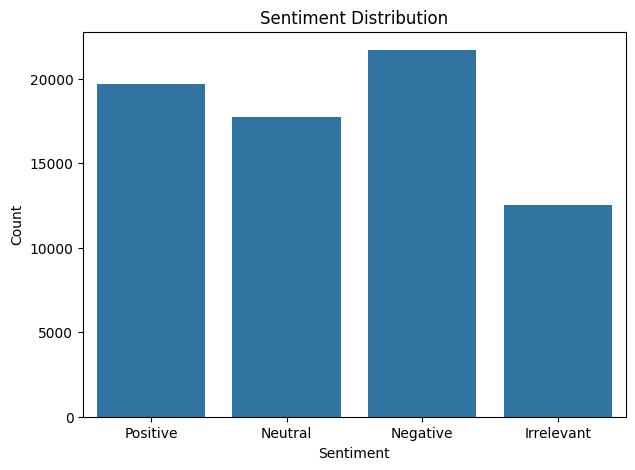

In [7]:
# Sentiment distribution

plt.figure(figsize=(7, 5))
sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [8]:
# Sentiment percentage

sentiment_counts = df["Sentiment"].value_counts()
sentiment_percentage = df["Sentiment"].value_counts(normalize=True) * 100

sentiment_summary = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percentage.round(2)
})

sentiment_summary

,Count,Percentage
Sentiment,,
Negative,21698,30.28
Positive,19713,27.51
Neutral,17708,24.71
Irrelevant,12537,17.50


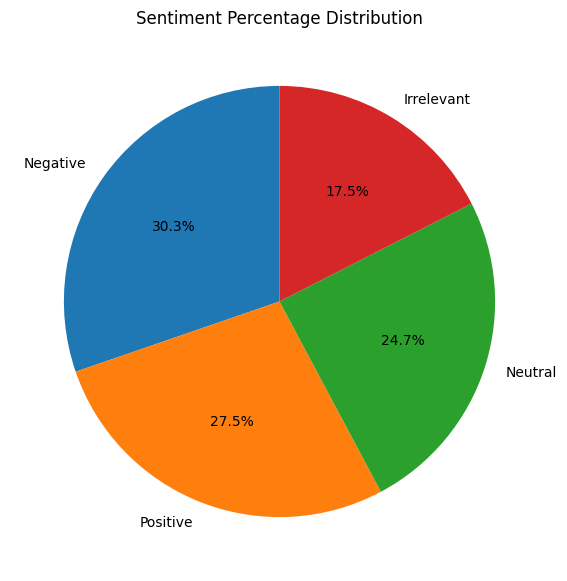

In [9]:
# Pie chart of sentiments

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage Distribution")
plt.show()

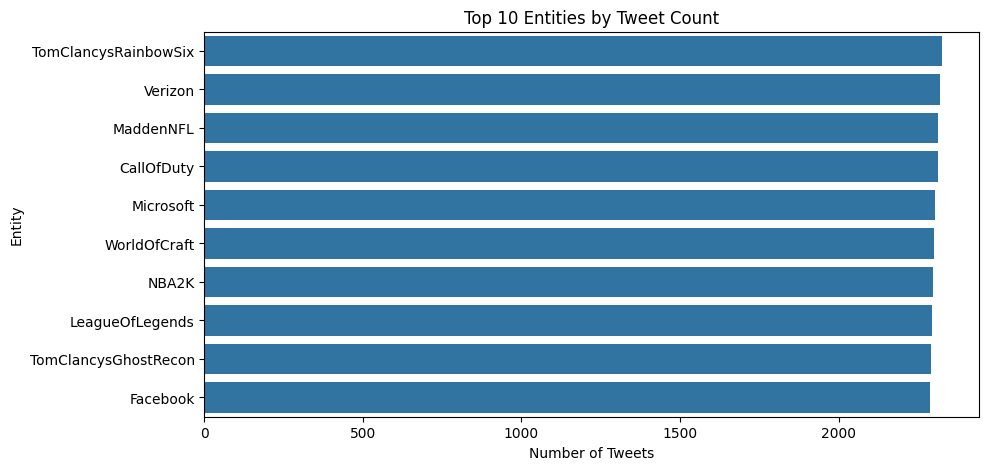

In [10]:
# Top 10 entities by number of tweets

top_entities = df["Entity"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_entities.values, y=top_entities.index)

plt.title("Top 10 Entities by Tweet Count")
plt.xlabel("Number of Tweets")
plt.ylabel("Entity")
plt.show()

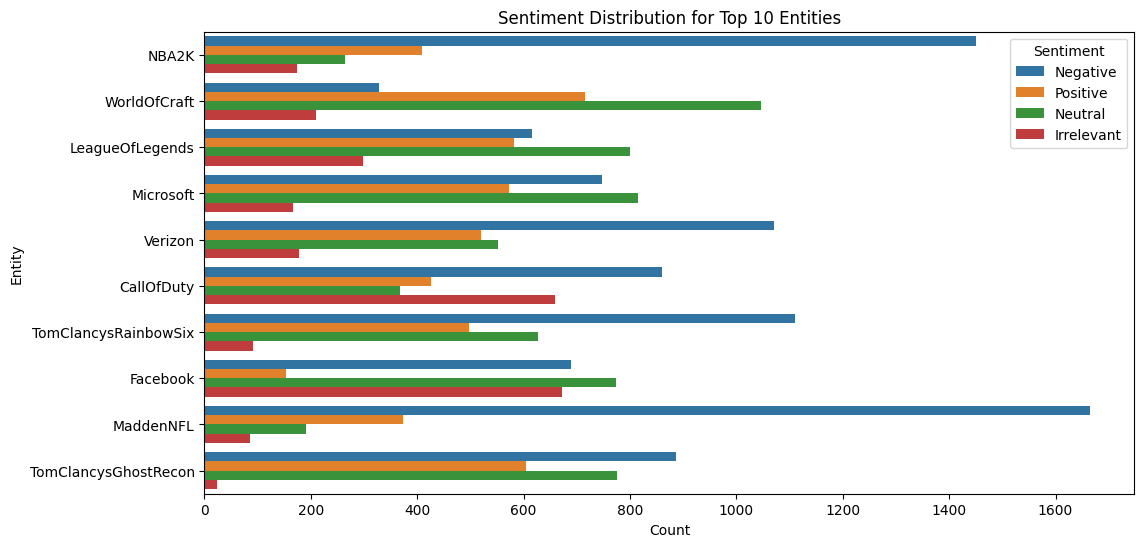

In [11]:
# Sentiment distribution for top 10 entities

top_entity_names = df["Entity"].value_counts().head(10).index
top_entity_data = df[df["Entity"].isin(top_entity_names)]

plt.figure(figsize=(12, 6))
sns.countplot(y="Entity", hue="Sentiment", data=top_entity_data)

plt.title("Sentiment Distribution for Top 10 Entities")
plt.xlabel("Count")
plt.ylabel("Entity")
plt.show()

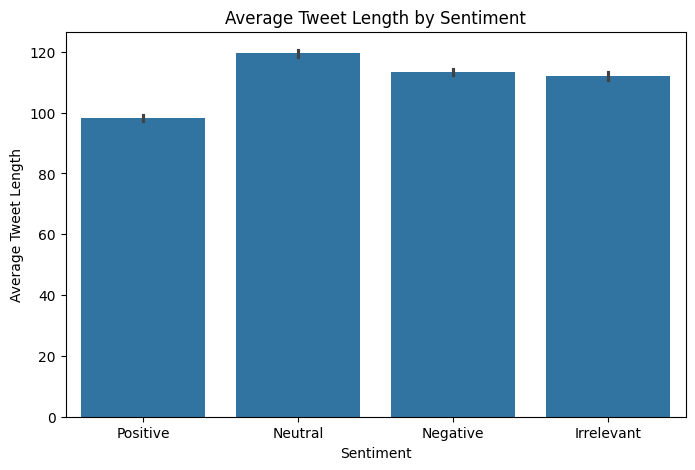

In [12]:
# Average tweet length by sentiment

df["Tweet_Length"] = df["Tweet"].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.barplot(x="Sentiment", y="Tweet_Length", data=df)

plt.title("Average Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Tweet Length")
plt.show()

In [13]:
# Number of tweets by sentiment and entity

sentiment_entity_table = pd.crosstab(df["Entity"], df["Sentiment"])

sentiment_entity_table.head(10)

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,185,565,1197,302
ApexLegends,185,574,913,606
AssassinsCreed,256,365,153,1382
Battlefield,907,445,342,561
Borderlands,238,415,581,972
CS-GO,620,335,523,717
CallOfDuty,660,861,367,426
CallOfDutyBlackopsColdWar,545,540,340,817
Cyberpunk2077,457,360,456,902


In [14]:
# Final observations

print("Task 04 - Sentiment Analysis Observations")
print("1. The dataset contains tweets related to different brands, games, and topics.")
print("2. Sentiments are categorized as Positive, Negative, Neutral, and Irrelevant.")
print("3. Sentiment distribution helps understand public opinion toward different entities.")
print("4. Entity-wise sentiment analysis shows which brands or topics received more positive or negative reactions.")
print("5. Visualizations make it easier to identify sentiment patterns in social media data.")

Task 04 - Sentiment Analysis Observations
1. The dataset contains tweets related to different brands, games, and topics.
2. Sentiments are categorized as Positive, Negative, Neutral, and Irrelevant.
3. Sentiment distribution helps understand public opinion toward different entities.
4. Entity-wise sentiment analysis shows which brands or topics received more positive or negative reactions.
5. Visualizations make it easier to identify sentiment patterns in social media data.


# Task 04 - Sentiment Analysis and Visualization

This project is part of my Data Science Internship at Prodigy InfoTech.

## Objective
Analyze and visualize sentiment patterns in social media data to understand public opinion and attitudes toward specific topics or brands.

## Dataset
Twitter Entity Sentiment Analysis dataset.

## Steps Performed
- Loaded the dataset
- Renamed columns
- Checked missing values
- Cleaned missing and duplicate records
- Analyzed sentiment distribution
- Visualized sentiment patterns
- Compared sentiments across top entities

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

## Conclusion

The sentiment analysis shows how users express opinions toward different entities on social media. The dataset contains Positive, Negative, Neutral, and Irrelevant sentiments. Visualizations such as count plots, pie charts, and entity-wise sentiment charts helped identify public opinion patterns across different brands and topics.